# Merging Climate Datasets Exercise

Work through this notebook to practice harmonizing and merging two climate datasets that differ in temporal cadence and spatial resolution.

You will: 
- Load two public NOAA datasets directly from the cloud
- Subset to the continental US (use 230°E–300°E in longitude since the data span 0–360°)
- Use `xr.resample` to aggregate time and `xr.interp` to match grids
- Combine the variables with `xr.merge` for joint analysis

Refer back to the answer key after attempting each step.


## 1. Setup


In [54]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    ccrs = None
    cfeature = None

TEMP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/surface/air.sig995.2020.nc"
PRECIP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/cpc_global_precip/precip.2020.nc"

# reverse range of lats and added slice functions
LAT_RANGE = slice(50, 20)  # degrees North
LON_RANGE_360 = slice(230, 300)  # degrees East (equivalent to -130° to -60°)
LON_RANGE_180 = slice(-130, -60)  # convenience if a dataset uses -180° to 180°

TIME_RANGE = slice("2020-06-01", "2020-06-30")


## 2. Load the datasets

Open both remote datasets with `xr.open_dataset`, passing a reasonable chunk size for the time dimension. Assign the resulting objects to `air` and `precip`.


In [12]:
# TODO: load the air temperature and precipitation datasets.
# Example: air = xr.open_dataset(..., chunks={"time": 8})
#raise NotImplementedError("Assign datasets to `air` and `precip`.")

air = xr.open_dataset(TEMP_URL, chunks={"time": 24})
precip = xr.open_dataset(PRECIP_URL, chunks={"time": 24})

## 3. Subset to the continental United States and June 2020

Select the bounding box provided above and limit the time range to June 2020 for both datasets. Store the results in `air_us` and `precip_us`.
Remember that longitude runs from 0° to 360°, so select 230°E–300°E. Check whether each coordinate is ascending or descending before building the slice.


In [49]:
# TODO: subset both datasets using `sel`, handling coordinate ordering as needed.
#raise NotImplementedError("Create `air_us` and `precip_us`.")

air_us = air.sel(time=TIME_RANGE, lon=LON_RANGE_360, lat=LAT_RANGE)
precip_us = precip.sel(time=TIME_RANGE, lon=LON_RANGE_360, lat=LAT_RANGE)

## 4. Align temporal cadence

Aggregate the six-hourly air temperatures to daily means with `xr.resample`. Name the resulting DataArray `air_daily`.


In [50]:
# TODO: use xr.resample to create daily means.
#raise NotImplementedError("Create `air_daily`.")

air_daily = air_us.resample(time='1D').mean()


## 5. Interpolate to the precipitation grid

Use `xr.interp` to interpolate the daily air temperatures onto the precipitation grid (`precip_us.lat` and `precip_us.lon`). Store the interpolated result in `air_interp`.


In [37]:
# TODO: interpolate the resampled temperature field onto the precipitation grid.
#raise NotImplementedError("Create `air_interp`.")

air_interp = air_daily.interp(lat=precip_us.lat, lon=precip_us.lon)


## 6. Merge the datasets

Convert the aligned arrays into datasets with clear variable names and merge them with `xr.merge`. Save the output as `merged`.


In [103]:
# TODO: build datasets and merge them into one object named `merged`.
#raise NotImplementedError("Create `merged`.")

merged = xr.merge([precip_us, air_interp])
# rename variables
merged = merged.rename({'precip': 'daily_precip', 'air': 'air_temperature'})


## 7. Inspect your result

Once your pipeline runs without `NotImplementedError`, evaluate the following cell to sanity-check the merged dataset.


In [ ]:
# The assertions below should pass once you have completed the exercise.
assert set(merged.data_vars) == {"air_temperature", "daily_precip"}
assert merged.air_temperature.dims == merged.daily_precip.dims
print(merged)


<xarray.Dataset> Size: 2MB
Dimensions:          (time: 30, lat: 60, lon: 140)
Coordinates:
  * lat              (lat) float32 240B 49.75 49.25 48.75 ... 21.25 20.75 20.25
  * lon              (lon) float32 560B 230.2 230.8 231.2 ... 298.8 299.2 299.8
  * time             (time) datetime64[ns] 240B 2020-06-01 ... 2020-06-30
Data variables:
    daily_precip     (time, lat, lon) float32 1MB dask.array<chunksize=(16, 60, 140), meta=np.ndarray>
    air_temperature  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 60, 140), meta=np.ndarray>
Attributes:
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.0
    version:                         V1.0
    title:                           CPC GLOBAL PRCP V1.0 RT
    dataset_title:                   CPC GLOBAL PRCP V1.0
    Source:                          ftp://ftp.cpc.ncep.noaa.gov/precip/CPC_U...
    References:                      https://www.psl.noaa.gov/data/gridded/

## 8. Check In

- Render both variables at the first timestep on a `cartopy` map to verify alignment visually (PlateCarree works well).
- Build a scatter plot comparing colocated temperature and precipitation values across the merged domain.
- Save the merged output with `to_netcdf` for future analysis.


In [ ]:
# must save merged xarray Dataset as netcdf3 format to avoid
# Attribute error NetCDF: String match to name in use
merged.to_netcdf('merged_air_precip.nc', format='NETCDF3_64BIT')

In [120]:
# make map function
def make_map(data, lon, lat, title, cmap_title, data2, cmap_title2, 
        pt_col, marker, plon, plat, cmap='RdYlGn_r'):

    #lon_grid, lat_grid = np.meshgrid(lon_range, lat_range)
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # projection
    proj = ccrs.PlateCarree()

    # figure
    fig, ax = plt.subplots(figsize=(15,15),subplot_kw=dict(projection=proj))

    # add title, axis labels, and coastlines
    ax.coastlines()

    # add gridded data and colorbar
    cs = ax.contourf(lon_grid, lat_grid, data, 10,
        cmap=cmap, transform=proj, extend='both')
    cb = fig.colorbar(cs,shrink=0.22)
    cb.set_label(cmap_title)
    # add gridded data and colorbar
    cs2 = ax.contour(lon_grid, lat_grid, data2, 10,
        cmap="Blues", transform=proj, extend='both')
    cb2 = fig.colorbar(cs2,shrink=0.22)
    cb2.set_label(cmap_title2)

    # add point data
    ax.scatter(plon, plat, transform=proj, marker=marker, c=pt_col)
    
    # title
    ax.set_title(title)
    # add gridlines
    gl = ax.gridlines(draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    #ax.set_ylim(48,72); ax.set_xlim(-80,40)

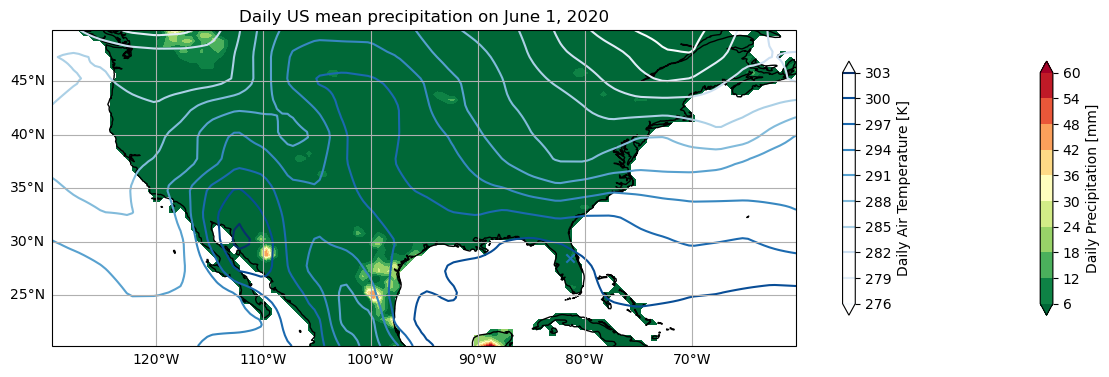

In [ ]:
# Daily US mean precipitation on June 1, 2020
make_map(
    data=merged.isel(time=0).daily_precip, 
    data2=merged.isel(time=0).air_temperature, 
    lon=merged.lon.values, 
    lat=merged.lat.values, 
    title='Daily US mean precipitation on June 1, 2020',
    cmap_title="Daily Precipitation [mm]",
    cmap_title2="Daily Air Temperature [K]",
    marker='x',
    pt_col='k',
    plon=278.6,
    plat=28.5)

Text(0.5, 0, 'Daily Precipitation [mm]')

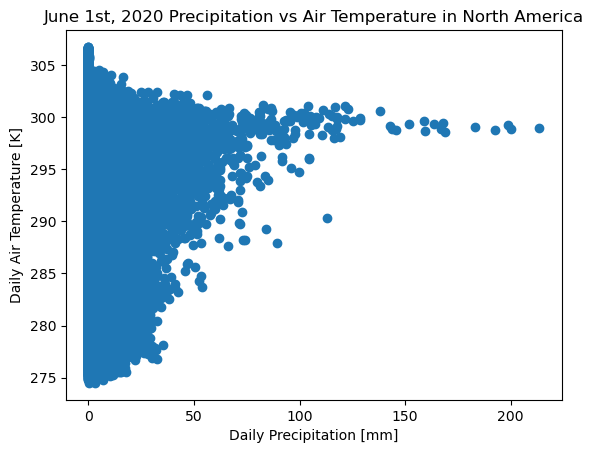

In [ ]:
# scatter plot of daily precipitation vs air temperatures on June 1, 2020
plt.scatter(merged.daily_precip.values, merged.air_temperature.values)
plt.title('June 1st, 2020 Precipitation vs Air Temperature in North America')
plt.ylabel('Daily Air Temperature [K]')
plt.xlabel('Daily Precipitation [mm]')